# Intro

**Seminar by @Elad_Benjo**

In this notebook I will attempt to develop a new model for nowcsating of the Israeli GDP.

Our efforts would be towards a DFM, since we have various frequencies and high demensional data.

In [ ]:
from google.colab import drive
import sys

drive.mount('/content/drive')
sys.path.append('/content/drive/MyDrive/gdp_nowcasting_seminar/src')

Mounted at /content/drive


## Papers

https://www.federalreserve.gov/econres/ifdp/files/ifdp1385.pdf

# Pre-model Prep

In [ ]:
import pandas as pd

In [ ]:
daily_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/feature_selected/daily_data.pkl')

In [ ]:
monthly_df = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/feature_selected/monthly_data.pkl')

In [ ]:
monthly_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 364 entries, 1995-01-01 to 2025-04-01
Freq: MS
Data columns (total 43 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Total refunds from the Income Tax Department                                    339 non-null    float64
 1   self employed returns                                                           339 non-null    float64
 2   Cancellations Deductions                                                        352 non-null    float64
 3   Capital Gas Tax Refunds                                                         351 non-null    float64
 4   Cancellation companies                                                          352 non-null    float64
 5   Purchase returns                                                                351 non-null    flo

0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42

In [ ]:
monthly_df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]] = monthly_df.iloc[:, [0, 1, 2, 3, 4, 5, 6, 7, 10, 16, 19, 20, 21, 23, 24, 25, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42]].shift(1)

In [ ]:
import preprocessing

In [ ]:
df_X = preprocessing.merge_series_freq({'d': daily_df, 'm': monthly_df})

In [ ]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9482 entries, 1995-01-01 to 2025-08-01
Data columns (total 47 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   d_TA125                                                                           4879 non-null   float64
 1   d_SP500                                                                           6135 non-null   float64
 2   d_USD_ILS                                                                         5969 non-null   float64
 3   d_SPGSCI                                                                          6135 non-null   float64
 4   m_Total refunds from the Income Tax Department                                    339 non-null    float64
 5   m_self employed returns                                                           339 non-nul

In [ ]:
df_X = df_X.asfreq("D")

In [ ]:
print(df_X.index.freq)

<Day>


In [ ]:
df_X.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 11171 entries, 1995-01-01 to 2025-08-01
Freq: D
Data columns (total 47 columns):
 #   Column                                                                            Non-Null Count  Dtype  
---  ------                                                                            --------------  -----  
 0   d_TA125                                                                           4879 non-null   float64
 1   d_SP500                                                                           6135 non-null   float64
 2   d_USD_ILS                                                                         5969 non-null   float64
 3   d_SPGSCI                                                                          6135 non-null   float64
 4   m_Total refunds from the Income Tax Department                                    339 non-null    float64
 5   m_self employed returns                                                           33

## Publication Shifts

Tax information is relead in a 10 days delay

In [ ]:
df_X.iloc[:, [4, 5, 6, 7, 8, 9, 10, 11, 14, 20, 23, 24, 25, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]] = df_X.iloc[:, [4, 5, 6, 7, 8, 9, 10, 11, 14, 20, 23, 24, 25, 27, 28, 29, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46]].shift(10)

CPI is 15 days later  
Consumer Trust Index is 12 days later  
Unemployment rate is 16 days later  
Real Credit Card Usage is 3 days later


In [ ]:
df_X.iloc[:, [17]] = df_X.iloc[:, [17]].shift(15)
df_X.iloc[:, [19]] = df_X.iloc[:, [19]].shift(12)
df_X.iloc[:, [12]] = df_X.iloc[:, [12]].shift(16)
df_X.iloc[:, [21]] = df_X.iloc[:, [21]].shift(3)

real salary delay is 50 days then drop it

In [ ]:
df_X = df_X.drop(df_X.columns[26], axis=1)

drop the first 2 rows, and anything beyond 16.1.25

In [ ]:
df_X = df_X.iloc[2:]
df_X = df_X[:'2025-01-16']

## Train-Test Split

I split the data according to the model currently used by the Ministry of Finance, in order to maintain a relevant basis for performance comparison.

In [ ]:
df_X.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_X.pkl')

In [ ]:
x_train = df_X[:'2022-01-16']
x_test = df_X['2022-01-17':]

In [ ]:
x_train.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/x_train.pkl')

In [ ]:
x_test.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/x_test.pkl')

In [ ]:
df_Y = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/stationary/quarterly_data.pkl')

In [ ]:
df_Y.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 119 entries, 1995-06-30 to 2024-12-31
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   GDP     119 non-null    float64
 1   C       119 non-null    float64
 2   G       115 non-null    float64
 3   I       119 non-null    float64
 4   EX      119 non-null    float64
 5   IM      119 non-null    float64
dtypes: float64(6)
memory usage: 6.5 KB


In [ ]:
df_Y.tail(20)

,GDP,C,G,I,EX,IM
Date,,,,,,
2020-03-31,-0.020815,-0.059381,-0.032948,0.005003,-0.030563,-0.066587
2020-06-30,-0.086301,-0.122846,0.013079,-0.140037,-0.085846,-0.114879
2020-09-30,0.085868,0.080171,0.025859,0.059847,0.102935,-0.008056
2020-12-31,0.025544,0.044362,0.024968,0.132744,0.026366,0.169621
2021-03-31,0.004977,0.004431,0.007891,-0.018693,0.040784,0.029436
2021-06-30,0.034456,0.063183,-0.001098,0.033092,0.024298,0.044995
2021-09-30,0.019257,0.013908,-0.026294,0.034772,0.038396,0.033290
2021-12-31,0.043839,0.034346,0.010034,0.039539,0.064620,0.065860
2022-03-31,-0.006193,0.010369,-0.014388,0.031372,-0.001565,0.033355


In [ ]:
y_train = df_Y[:'2021-12-31']
y_test = df_Y['2022-01-01':]

In [ ]:
y_train.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_train.pkl')

In [ ]:
y_test.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/y_test.pkl')

In [ ]:
x_train.tail()

,d_TA125,d_SP500,d_USD_ILS,d_SPGSCI,m_Total refunds from the Income Tax Department,m_self employed returns,m_Cancellations Deductions,m_Capital Gas Tax Refunds,m_Cancellation companies,m_Purchase returns,...,m_Goods and services,m_Independents advances,m_Self-employed tax differences,m_Non-profit institution tax,m_tax differential companies,m_Companies advances,m_Income tax for self-employed dividuals and companies (advances and deductions),m_Deduction from salary,m_Deductions and the capital market,m_Total Income Tax Division Net
Date,,,,,,,,,,,,,,,,,,,,,
2022-01-12,0.015241,0.002814,-0.004608,0.012775,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-13,0.006246,-0.014346,0.001806,-0.009244,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-14,NaN,0.000820,-0.001726,0.011274,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-15,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2022-01-16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
y_train.tail()

,GDP,C,G,I,EX,IM
Date,,,,,,
2020-12-31,0.025544,0.044362,0.024968,0.132744,0.026366,0.169621
2021-03-31,0.004977,0.004431,0.007891,-0.018693,0.040784,0.029436
2021-06-30,0.034456,0.063183,-0.001098,0.033092,0.024298,0.044995
2021-09-30,0.019257,0.013908,-0.026294,0.034772,0.038396,0.033290
2021-12-31,0.043839,0.034346,0.010034,0.039539,0.064620,0.065860


## Remove empty rows

In [ ]:
import pandas as pd

In [ ]:
df_X_train = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_X_train.pkl')

In [ ]:
# מספר השורות הכולל
total_rows = len(x_train)

# כמה שורות הן לגמרי ריקות (כל העמודות NaN)
empty_rows = x_train.isna().all(axis=1).sum()

# אחוז שורות ריקות
empty_pct = empty_rows / total_rows * 100

print(f"Total rows: {total_rows}")
print(f"Completely empty rows: {empty_rows}")
print(f"Percentage empty: {empty_pct:.2f}%")


Total rows: 9876
Completely empty rows: 3219
Percentage empty: 32.59%


In [ ]:
# 1. remove rows that contain all NaN
df_x_train = df_X_train.dropna(how="all")

# 2. recreate continues daily index
full_index = pd.date_range(df_X_train.index.min(), df_X_train.index.max(), freq="D")
df_x_train = df_x_train.reindex(full_index)

print(df_X_train.shape, " -> ", df_x_train.shape)


(9860, 47)  ->  (9860, 47)


## Z-Score

In [ ]:
import stats_trans

In [ ]:
mu, sigma = stats_trans.fit_zscore(x_train)

In [ ]:
x_train_z_score = stats_trans.transform_zscore(x_train, mu, sigma)

In [ ]:
x_train_z_score.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_x_train_z_score.pkl')

## DFM

In [ ]:
import pandas as pd

In [ ]:
x_train_z_score = pd.read_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/df_x_train_z_score.pkl')

In [ ]:
import dfm

In [ ]:
import importlib

In [ ]:
importlib.reload(dfm)

<module 'dfm' from '/content/drive/MyDrive/gdp_nowcasting_seminar/src/dfm.py'>

In [ ]:
max_factors = dfm.max_possible_factors(init_tester)
print(f"Max factors you can safely request: {max_factors}")


Max factors you can safely request: 46


### pre-train

fill the NaN to initialize weights for the model

In [ ]:
x_train_init = dfm.make_within_month_filled(x_train_z_score)

In [ ]:
import statsmodels.api as sm

In [ ]:
k_factors = 1
factor_order = 1

mod_init = sm.tsa.DynamicFactor(
    x_train_init,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
init_powell = mod_init.fit(method="powell", maxiter=15, disp=True)


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_optimize.py:3398: RuntimeWarning: Maximum number of iterations has been exceeded.
  res = _minimize_powell(func, x0, args, callback=callback, **opts)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 55.708953
         Iterations: 15
         Function evaluations: 14903


In [ ]:
import pickle

with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_powell_fit.pkl", "wb") as f:
    pickle.dump(init_powell, f)


In [ ]:
init_res = mod_init.fit(
    start_params=init_powell.params,
    method="lbfgs",
    maxiter=50,
    full_output=True,
    disp=True,
    optim_score='approx',
    optim_kwds={
        "pgtol": 1e-6,
        "maxfun": 5000
    }
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/optimizer.py:21: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: optim_kwds. After release 0.14, this will raise.
  warnings.warn(


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/init_res_fit.pkl", "wb") as f:
    pickle.dump(init_res, f)


In [ ]:
print(f"Powell LLF: {init_powell.llf}")
print(f"LBFGS LLF:  {init_res.llf}")

Powell LLF: -550181.6237712372
LBFGS LLF:  -548316.9486236731


### original data

after weights were initialized we can adjust to the set with NaNs

In [ ]:
mod_final = sm.tsa.DynamicFactor(
    x_train_z_score,
    k_factors=k_factors,
    factor_order=factor_order,
    error_cov_type="diagonal"
)

In [ ]:
final_res = mod_final.fit(
    start_params=init_res.params,
    method="lbfgs",
    maxiter=50,
    disp=True
)

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
with open("/content/drive/MyDrive/gdp_nowcasting_seminar/models/mod_final_fit.pkl", "wb") as f:
    pickle.dump(final_res, f)


In [ ]:
print(f"Final LLF:  {final_res.llf}")

Final LLF:  -45160.92617625276


In [ ]:
smoothed = final_res.smoothed_state

In [ ]:
factor_series = smoothed[0, :]

In [ ]:
factor_df = pd.DataFrame({
    "factor": factor_series
}, index=mod.data.row_labels)

In [ ]:
factor_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9876 entries, 1995-01-03 to 2022-01-16
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   factor  9876 non-null   float64
dtypes: float64(1)
memory usage: 154.3 KB


### evaluations

In [ ]:
import eda

In [ ]:
pip install "vl-convert-python>=1.6.0"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 33.0/33.0 MB 21.1 MB/s eta 0:00:00


In [ ]:
eda.plot_time_series_altair(factor_df)

alt.Chart(...)

In [ ]:
factor_df.to_pickle('/content/drive/MyDrive/gdp_nowcasting_seminar/Data/pickles/dfm/factor_df.pkl')

In [ ]:
loadings = final_res.params.filter(like='loading')
print(loadings)

loading.f1.d_TA125                                                                             0.537440
loading.f1.d_SP500                                                                             0.365789
loading.f1.d_USD_ILS                                                                          -0.280776
loading.f1.d_SPGSCI                                                                            0.286628
loading.f1.m_Total refunds from the Income Tax Department                                     -0.110480
loading.f1.m_self employed returns                                                            -0.201851
loading.f1.m_Cancellations Deductions                                                          0.003235
loading.f1.m_Capital Gas Tax Refunds                                                           0.018311
loading.f1.m_Cancellation companies                                                            0.140439
loading.f1.m_Purchase returns                                   

In [ ]:
correlations = x_train_z_score.corrwith(factor_df['factor'])
print(correlations.sort_values(ascending=False))


m_The combed dex of the state of the economy                                        0.981359
m_Deductions and the capital market                                                 0.933504
m_Deduction from salary                                                             0.932726
m_Total Income Tax Division Net                                                     0.926431
m_real_credit_card                                                                  0.895111
d_TA125                                                                             0.777356
m_Non-profit institution tax                                                        0.721322
d_SP500                                                                             0.574668
m_VAT Fancial Institutions (Salary)                                                 0.567963
m_excess expenses                                                                   0.524046
m_Apartments sold at an annual rate                                   

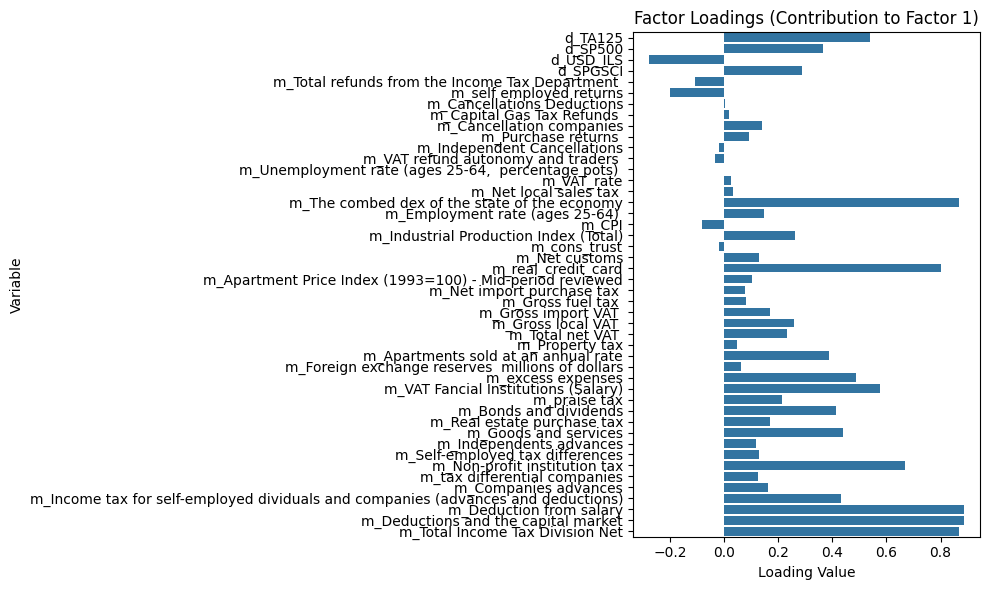

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

loadings = final_res.params.filter(like='loading')
loadings.index = [colname.replace('loading.f1.', '') for colname in loadings.index]

plt.figure(figsize=(10, 6))
sns.barplot(x=loadings.values, y=loadings.index)
plt.title('Factor Loadings (Contribution to Factor 1)')
plt.xlabel('Loading Value')
plt.ylabel('Variable')
plt.tight_layout()
plt.show()
